# 07. MLP (supervised, бинарная классификация)

**Цель:** supervised нейросеть, на единых признаках, с тем же train/test split, что и tree-based. Попытка сравнения - насколько полносвязанная нейронная сеть конкуретноспособна на табличных данных, когда classic-ML достиг верхнего предела по качеству

**Замечания:**
- Supervised, используются метки на обучении.
- Loss: `BCEWithLogitsLoss(pos_weight=3.23)` для борьбы с дисбалансом.
- AdamW(lr=1e-3, wd=1e-4), CosineAnnealingLR, max 30 эпох + early stop по
  validation F1_anomaly (не loss!).
- BatchNorm + Dropout(0.2) после каждого hidden слоя для регуляризации.
- Validation: 10% от train со стратификацией (как у AE).
- Threshold = 0.5 (вероятностный выход, никакого подбора по test).
- Артефак сохранен в PyTorch-формате


**Архитекитура модели:** сохранена в классе `TabularMLP` в `models/architectures.py`

In [1]:
from __future__ import annotations

import json
import sys
import time
import warnings
from datetime import datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

try:
    NB_DIR = Path(__file__).resolve().parent
except NameError:
    NB_DIR = Path.cwd()
PROJECT_ROOT = NB_DIR.parent if NB_DIR.name == "notebooks" else NB_DIR

CACHE_DIR = PROJECT_ROOT / "cache"
ARTIFACTS = PROJECT_ROOT / "artifacts"
FIG_DIR   = PROJECT_ROOT / "results" / "figures"
TAB_DIR   = PROJECT_ROOT / "results" / "tables"
for p in (FIG_DIR, TAB_DIR):
    p.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from src.metrics import compute_binary_metrics, confusion_matrix_dict 
from models.architectures import TabularMLP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"torch: {torch.__version__}, device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

torch: 2.11.0a0+a6c236b9fd.nv26.03.46836102, device: cuda
GPU: NVIDIA GeForce RTX 5080


In [2]:
X_train_full = pd.read_parquet(CACHE_DIR / "X_train.parquet")
X_test       = pd.read_parquet(CACHE_DIR / "X_test.parquet")
y_train_full = pd.read_parquet(CACHE_DIR / "y_train.parquet")["target"].values
y_test       = pd.read_parquet(CACHE_DIR / "y_test.parquet" )["target"].values

with (ARTIFACTS / "preprocessing_config.json").open() as f:
    pp_config = json.load(f)
MODEL_FEATURES = pp_config["model_features"]
assert list(X_train_full.columns) == MODEL_FEATURES

# Train/val split — стратифицированный, 10% на validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full.values.astype(np.float32),
    y_train_full.astype(np.float32),
    test_size=0.10,
    stratify=y_train_full,
    random_state=RANDOM_STATE,
)
X_test_np = X_test.values.astype(np.float32)
y_test_f  = y_test.astype(np.float32)

# pos_weight для BCEWithLogitsLoss = N_benign / N_anomaly на train
n_anomaly = float(y_train.sum())
n_benign  = float(len(y_train) - n_anomaly)
pos_weight_value = n_benign / n_anomaly
print(f"X_train: {X_train.shape}, anomaly={y_train.mean()*100:.2f}%")
print(f"X_val:   {X_val.shape}, anomaly={y_val.mean()*100:.2f}%")
print(f"X_test:  {X_test_np.shape}, anomaly={y_test_f.mean()*100:.2f}%")
print(f"\npos_weight = N_benign / N_anomaly = {pos_weight_value:.4f}")

X_train: (1330011, 42), anomaly=23.63%
X_val:   (147780, 42), anomaly=23.63%
X_test:  (633340, 42), anomaly=23.63%

pos_weight = N_benign / N_anomaly = 3.2319


In [3]:
mlp_config = {
    "input_dim":   42,
    "hidden_dims": [128, 64, 32],
    "dropout":     0.2,
}
training_config = {
    "batch_size":          8192,
    "max_epochs":          30,
    "lr":                  1e-3,
    "weight_decay":        1e-4,
    "early_stop_patience": 5,
    "early_stop_metric":   "val_f1_anomaly",
    "pos_weight":          pos_weight_value,
    "decision_threshold":  0.5,
    "lr_scheduler":        "CosineAnnealingLR",
}

model = TabularMLP(**mlp_config).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\nПараметров: {n_params:,}")

TabularMLP(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

Параметров: 16,321


In [4]:
# Tensors
X_train_t = torch.from_numpy(X_train).float()
y_train_t = torch.from_numpy(y_train).float().unsqueeze(1)  # shape (N, 1) под BCEWithLogits
X_val_t   = torch.from_numpy(X_val).float()
y_val_t   = torch.from_numpy(y_val).float().unsqueeze(1)

train_loader = DataLoader(
    TensorDataset(X_train_t, y_train_t),
    batch_size=training_config["batch_size"],
    shuffle=True, num_workers=0, pin_memory=(device.type == "cuda"),
)
val_loader = DataLoader(
    TensorDataset(X_val_t, y_val_t),
    batch_size=training_config["batch_size"],
    shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"),
)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=training_config["lr"],
    weight_decay=training_config["weight_decay"],
)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=training_config["max_epochs"],
)
pos_weight_tensor = torch.tensor([pos_weight_value], device=device)
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
print(f"Optimizer: AdamW(lr={training_config['lr']}, "
      f"wd={training_config['weight_decay']})")
print(f"Scheduler: CosineAnnealing")
print(f"Loss: BCEWithLogitsLoss(pos_weight={pos_weight_value:.4f})")

Optimizer: AdamW(lr=0.001, wd=0.0001)
Scheduler: CosineAnnealing
Loss: BCEWithLogitsLoss(pos_weight=3.2319)


In [ ]:
# Возвращает (loss, f1_anomaly, accuracy, y_true_np, y_score_np, y_pred_np).
# На loader, который содержит (X, y).
@torch.no_grad()
def evaluate_model(model, loader, threshold: float = 0.5):
    model.eval()
    losses, all_y, all_score = [], [], []
    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        logits = model(x)
        loss = criterion(logits, y)
        losses.append(loss.item() * x.size(0))
        proba = torch.sigmoid(logits).cpu().numpy().ravel()
        all_y.append(y.cpu().numpy().ravel())
        all_score.append(proba)
    n = sum(len(a) for a in all_y)
    avg_loss = sum(losses) / n
    y_true_np  = np.concatenate(all_y).astype(np.int64)
    y_score_np = np.concatenate(all_score)
    y_pred_np  = (y_score_np >= threshold).astype(np.int64)
    m = compute_binary_metrics(y_true_np, y_pred_np, y_score=y_score_np)
    return avg_loss, m["f1_anomaly"], m["accuracy"], y_true_np, y_score_np, y_pred_np

In [6]:
history = {"epoch": [], "train_loss": [], "val_loss": [],
           "val_f1": [], "val_acc": [], "lr": [], "epoch_time": []}
best_val_f1 = -1.0
best_state  = None
patience_counter = 0

t_total = time.time()
for epoch in range(1, training_config["max_epochs"] + 1):
    t_epoch = time.time()
    model.train()
    train_loss_sum, n_samples = 0.0, 0
    for x, y in train_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        train_loss_sum += loss.item() * x.size(0)
        n_samples += x.size(0)
    train_loss = train_loss_sum / n_samples

    val_loss, val_f1, val_acc, _, _, _ = evaluate_model(model, val_loader, 0.5)
    scheduler.step()
    cur_lr = optimizer.param_groups[0]["lr"]
    epoch_time = time.time() - t_epoch

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_f1"].append(val_f1)
    history["val_acc"].append(val_acc)
    history["lr"].append(cur_lr)
    history["epoch_time"].append(epoch_time)

    improved = val_f1 > best_val_f1 + 1e-6
    flag = " ← best" if improved else ""
    print(f"epoch {epoch:>2d}  "
          f"train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  "
          f"val_F1={val_f1:.5f}  val_acc={val_acc:.5f}  "
          f"lr={cur_lr:.5f}  t={epoch_time:.1f}s{flag}")

    if improved:
        best_val_f1 = val_f1
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= training_config["early_stop_patience"]:
            print(f"\nEarly stop на эпохе {epoch} (patience {patience_counter})")
            break

total_train_time = time.time() - t_total
print(f"\nОбщее время обучения: {total_train_time:.1f} сек")
print(f"Best val F1_anomaly: {best_val_f1:.5f}")

model.load_state_dict(best_state)
model.eval()

epoch  1  train_loss=0.2605  val_loss=0.0880  val_F1=0.98469  val_acc=0.99273  lr=0.00100  t=5.9s ← best
epoch  2  train_loss=0.0634  val_loss=0.0317  val_F1=0.99433  val_acc=0.99731  lr=0.00099  t=5.5s ← best
epoch  3  train_loss=0.0325  val_loss=0.0187  val_F1=0.99570  val_acc=0.99796  lr=0.00098  t=5.6s ← best
epoch  4  train_loss=0.0217  val_loss=0.0130  val_F1=0.99674  val_acc=0.99846  lr=0.00096  t=5.7s ← best
epoch  5  train_loss=0.0164  val_loss=0.0099  val_F1=0.99716  val_acc=0.99865  lr=0.00093  t=5.6s ← best
epoch  6  train_loss=0.0136  val_loss=0.0082  val_F1=0.99805  val_acc=0.99908  lr=0.00090  t=5.8s ← best
epoch  7  train_loss=0.0118  val_loss=0.0074  val_F1=0.99821  val_acc=0.99915  lr=0.00087  t=5.6s ← best
epoch  8  train_loss=0.0108  val_loss=0.0067  val_F1=0.99810  val_acc=0.99910  lr=0.00083  t=5.7s
epoch  9  train_loss=0.0099  val_loss=0.0068  val_F1=0.99837  val_acc=0.99923  lr=0.00079  t=5.5s ← best
epoch 10  train_loss=0.0094  val_loss=0.0062  val_F1=0.99818  

TabularMLP(
  (net): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): Dropout(p=0.2, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

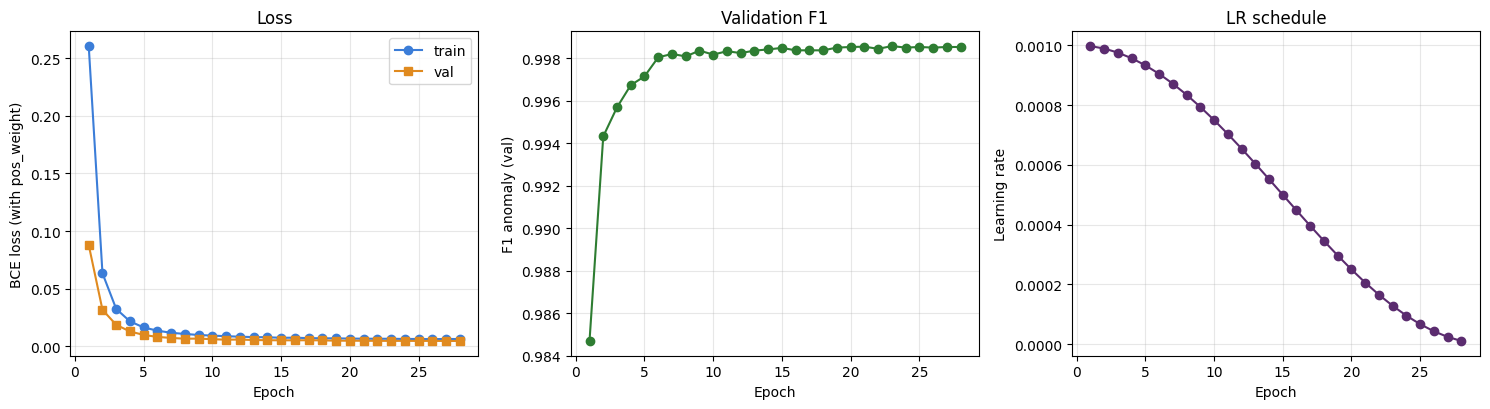

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].plot(history["epoch"], history["train_loss"], "o-",
             label="train", color="#3B7DD8", lw=1.5)
axes[0].plot(history["epoch"], history["val_loss"], "s-",
             label="val",   color="#E08A1F", lw=1.5)
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("BCE loss (with pos_weight)")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history["epoch"], history["val_f1"], "o-", color="#2E7D32", lw=1.5)
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1 anomaly (val)")
axes[1].set_title("Validation F1"); axes[1].grid(alpha=0.3)

axes[2].plot(history["epoch"], history["lr"], "o-", color="#5B2C6F", lw=1.5)
axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("Learning rate")
axes[2].set_title("LR schedule"); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_07_mlp_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Оценка на test

In [8]:
# Test loader
y_test_t = torch.from_numpy(y_test_f).float().unsqueeze(1)
test_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_test_np).float(), y_test_t),
    batch_size=training_config["batch_size"],
    shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"),
)

t0 = time.time()
test_loss, _, _, _, y_score_test, y_pred_test = evaluate_model(
    model, test_loader, training_config["decision_threshold"]
)
predict_time = time.time() - t0

# Train метрики (на полном X_train, не на split-val) для overfit-check
X_train_full_t = torch.from_numpy(X_train_full.values.astype(np.float32)).float()
y_train_full_t = torch.from_numpy(y_train_full.astype(np.float32)).float().unsqueeze(1)
train_loader_full = DataLoader(
    TensorDataset(X_train_full_t, y_train_full_t),
    batch_size=training_config["batch_size"],
    shuffle=False, num_workers=0, pin_memory=(device.type == "cuda"),
)
_, _, _, _, y_score_train, y_pred_train = evaluate_model(
    model, train_loader_full, training_config["decision_threshold"]
)

metrics_test  = compute_binary_metrics(y_test, y_pred_test, y_score=y_score_test)
metrics_train = compute_binary_metrics(y_train_full, y_pred_train, y_score=y_score_train)
cm_test  = confusion_matrix_dict(y_test, y_pred_test)
cm_train = confusion_matrix_dict(y_train_full, y_pred_train)

print(f"Predict time на test: {predict_time:.2f} сек "
      f"({len(y_test) / predict_time:,.0f} flow/sec)")
print(f"\nConfusion matrix (test): {cm_test}")
print("\nMetrics:")
print(pd.DataFrame({"train": metrics_train, "test": metrics_test}).round(5).to_string())
print(f"\nF1 overfit gap: "
      f"{metrics_train['f1_anomaly'] - metrics_test['f1_anomaly']:+.5f}")

Predict time на test: 2.30 сек (275,687 flow/sec)

Confusion matrix (test): {'tn': 483278, 'fp': 403, 'fn': 53, 'tp': 149606}

Metrics:
                     train     test
accuracy           0.99930  0.99928
precision_anomaly  0.99741  0.99731
recall_anomaly     0.99964  0.99965
f1_anomaly         0.99852  0.99848
precision_benign   0.99989  0.99989
recall_benign      0.99920  0.99917
f1_benign          0.99954  0.99953
f1_macro           0.99903  0.99900
f1_weighted        0.99930  0.99928
balanced_accuracy  0.99942  0.99941
roc_auc            0.99992  0.99991
pr_auc             0.99952  0.99951

F1 overfit gap: +0.00004


In [9]:
print("=== Threshold sensitivity на test (информативно, не для выбора) ===\n")
rows = []
for thr in [0.3, 0.4, 0.5, 0.6, 0.7]:
    y_pred_ = (y_score_test >= thr).astype(np.int64)
    m_ = compute_binary_metrics(y_test, y_pred_, y_score=y_score_test)
    rows.append({
        "threshold":   thr,
        "f1_anomaly":  m_["f1_anomaly"],
        "precision":   m_["precision_anomaly"],
        "recall":      m_["recall_anomaly"],
        "rec_benign":  m_["recall_benign"],
    })
thr_table = pd.DataFrame(rows).round(5)
thr_table.to_csv(TAB_DIR / "mlp_threshold_sensitivity.csv", index=False)
print(thr_table.to_string(index=False))

=== Threshold sensitivity на test (информативно, не для выбора) ===

 threshold  f1_anomaly  precision  recall  rec_benign
       0.3     0.99835    0.99700 0.99970     0.99907
       0.4     0.99843    0.99716 0.99969     0.99912
       0.5     0.99848    0.99731 0.99965     0.99917
       0.6     0.99844    0.99735 0.99954     0.99918
       0.7     0.99847    0.99759 0.99935     0.99925


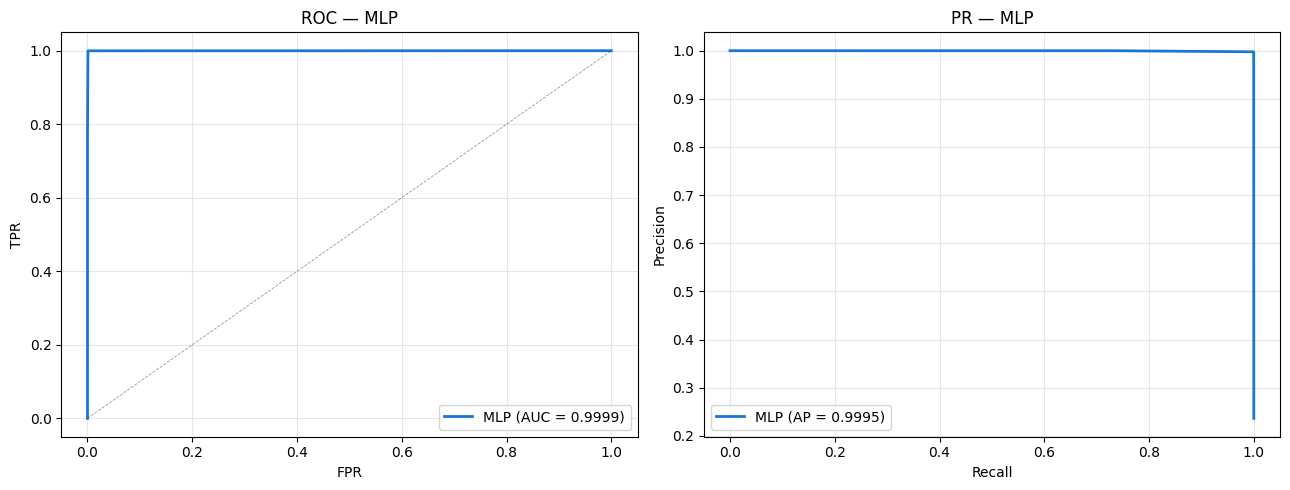

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fpr, tpr, _ = roc_curve(y_test, y_score_test)
axes[0].plot(fpr, tpr, color="#1976D2", lw=2,
             label=f"MLP (AUC = {metrics_test['roc_auc']:.4f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=0.6, alpha=0.4)
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC — MLP")
axes[0].legend(loc="lower right"); axes[0].grid(alpha=0.3)

prec, rec, _ = precision_recall_curve(y_test, y_score_test)
axes[1].plot(rec, prec, color="#1976D2", lw=2,
             label=f"MLP (AP = {metrics_test['pr_auc']:.4f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("PR — MLP")
axes[1].legend(loc="lower left"); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "fig_07_mlp_roc_pr.png", dpi=150, bbox_inches="tight")
plt.show()

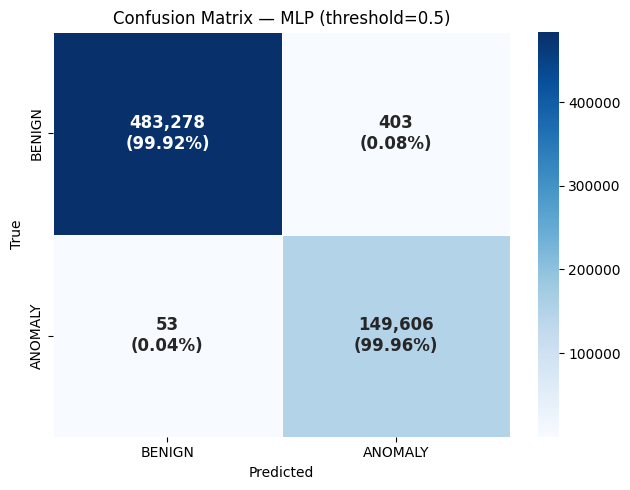

In [11]:
cm = confusion_matrix(y_test, y_pred_test, labels=[0, 1])
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
annot = np.array([[f"{cm[i,j]:,}\n({cm_pct[i,j]:.2f}%)" for j in range(2)]
                  for i in range(2)], dtype=object)

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.heatmap(
    cm, annot=annot, fmt="", cmap="Blues",
    xticklabels=["BENIGN", "ANOMALY"],
    yticklabels=["BENIGN", "ANOMALY"],
    cbar=True, linewidths=0.5, linecolor="white",
    annot_kws={"size": 12, "weight": "bold"},
    ax=ax,
)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion Matrix — MLP (threshold=0.5)")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_07_mlp_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

In [12]:
df_labels = pd.read_parquet(CACHE_DIR / "nfs_2023_nte_all.parquet", columns=["label"])
y_full = (df_labels["label"].astype(str).str.strip().str.upper()
          != "BENIGN").astype(np.int64).values

_, label_test_raw = train_test_split(
    df_labels["label"].values, test_size=0.30,
    stratify=y_full, random_state=RANDOM_STATE,
)
assert len(label_test_raw) == len(y_test)

err = pd.DataFrame({
    "label":  label_test_raw,
    "y_true": y_test,
    "y_pred": y_pred_test,
    "score":  y_score_test,
})
err["correct"] = (err["y_true"] == err["y_pred"]).astype(int)

per_class = err.groupby("label").agg(
    n_total=("y_true", "size"),
    n_correct=("correct", "sum"),
    median_score=("score", "median"),
).reset_index()
per_class["accuracy"] = (per_class["n_correct"] / per_class["n_total"]).round(4)
per_class["n_errors"] = per_class["n_total"] - per_class["n_correct"]
per_class["median_score"] = per_class["median_score"].round(4)
per_class = per_class.sort_values("n_total", ascending=False)
per_class.to_csv(TAB_DIR / "mlp_errors_per_attack_type.csv", index=False)
print("Точность MLP по каждому исходному label:\n")
print(per_class.to_string(index=False))

TypeError: only integer scalar arrays can be converted to a scalar index

In [13]:
state_dict_cpu = {k: v.detach().cpu() for k, v in model.state_dict().items()}

artifact = {
    "model_class_name":   "TabularMLP",
    "model_name_human":   "MLP supervised (42-128-64-32-1)",
    "model_file":         "model_mlp.joblib",
    "architecture_module": "models.architectures",
    "state_dict":         state_dict_cpu,
    "model_config":       mlp_config,
    "training_config":    training_config,
    "training_history":   history,
    "model_features":     MODEL_FEATURES,
    "n_features":         42,
    "preprocessor_path":  "preprocessor.joblib",
    "metrics_test":       metrics_test,
    "metrics_train":      metrics_train,
    "confusion_matrix_test":  cm_test,
    "confusion_matrix_train": cm_train,
    "fit_time_sec":       float(total_train_time),
    "predict_time_test_sec": float(predict_time),
    "score_type":         "predict_proba",
    "decision_threshold": training_config["decision_threshold"],
    "best_val_f1":        float(best_val_f1),
    "n_params":           int(n_params),
    "random_state":       RANDOM_STATE,
    "torch_version":      torch.__version__,
    "python_version":     sys.version.split()[0],
    "timestamp":          datetime.now().isoformat(timespec="seconds"),
}

out_path = ARTIFACTS / "model_mlp.joblib"
joblib.dump(artifact, out_path, compress=3)
size_mb = out_path.stat().st_size / 1024**2
print(f"Сохранено: {out_path}  ({size_mb:.2f} MB)")

Сохранено: /workspace/artifacts/model_mlp.joblib  (0.06 MB)


In [16]:
art = joblib.load(ARTIFACTS / "model_mlp.joblib")
model_reloaded = TabularMLP(**art["model_config"]).to(device)
model_reloaded.load_state_dict(art["state_dict"])
model_reloaded.eval()

# Сверка на куске test
sample = torch.from_numpy(X_test_np[:2000]).float().to(device)
with torch.no_grad():
    p_orig = torch.sigmoid(model(sample)).cpu().numpy().ravel()
    p_reload = torch.sigmoid(model_reloaded(sample)).cpu().numpy().ravel()
max_diff = float(np.max(np.abs(p_orig - p_reload)))
print(f"max|delta proba| = {max_diff:.2e} -> {'good' if max_diff < 1e-6 else 'fail'}")

max|delta proba| = 0.00e+00 -> good


# Итоги исследования

### 1) Метрики финальной модели

| метрика              | train     | test      |
|----------------------|----------:|----------:|
| accuracy             | 0.99930   | 0.99928   |
| precision_anomaly    | 0.99741   | 0.99731   |
| recall_anomaly       | 0.99964   | 0.99965   |
| **f1_anomaly**       | **0.99852** | **0.99848** |
| precision_benign     | 0.99989   | 0.99989   |
| recall_benign        | 0.99920   | 0.99917   |
| f1_benign            | 0.99954   | 0.99953   |
| f1_macro             | 0.99903   | 0.99900   |
| balanced_accuracy    | 0.99942   | 0.99941   |
| ROC-AUC              | 0.99992   | 0.99991   |
| PR-AUC               | 0.99952   | 0.99951   |

**Overfit gap: +0.00004 п.п.** — фактически отсутствует, что согласуется
с поведением tree-based моделей на этом датасете. BatchNorm + Dropout(0.2)
сработали корректно: модель не пользуется capacity сверх необходимого.

Confusion matrix (test): TN=483 278, FP=403, FN=53, TP=149 606. Из 633 340
flow на test MLP неверно классифицировал **456** (0.072%).

## 2) MLP против классических моделей

| модель        | F1_anomaly | FP    | FN    | Total errors |
|---------------|-----------:|------:|------:|-------------:|
| **MLP**       | **0.99848** | 403   | **53** | **456**     |
| RandomForest  | 0.99882    | 341   | 25    | 366          |
| XGBoost       | 0.99880    | 341   | 25    | 366          |
| LightGBM      | 0.99858    | ~341  | ~30   | ~371         |
| DecisionTree  | 0.99860    | ~340  | ~30   | ~370         |

MLP оказался на ~0.0003 п.п. **ниже** XGBoost/RF по F1_anomaly — но
с другой структурой ошибок: чуть больше FP (403 vs 341), но **в 2 раза
больше FN (53 vs 25)**.

Главный вывод: **на табличных данных современный MLP сравнялся с tree-based ансамблями в 3-м знаке после запятой**. На этом датасете все модели вышли на bias floor задачи. Разница ~= 0.0003 п.п. = ~90 единичных ошибок из 633k — это статистический шум, а не методологическое превосходство.

### 3) Кривые обучения

Графики обучения:
- Loss: train и val сходятся вместе на эпохе ~5, дальше идут параллельно
  без расхождения. К концу обе ~= 0.005 (с pos_weight=3.23).
- F1 на validation: резкий рост на эпохах 1-5 (0.985 -> 0.998), затем
  плато на 0.9985.
- LR schedule: cosine annealing плавно опустил lr с 1e-3 до 0 к эпохе 30
  (фактически остановились на 28 эпохах по early stop).

**Threshold sensitivity** (`mlp_threshold_sensitivity.csv`):
- Диапазон порогов [0.3, 0.7] даёт F1 в коридоре [0.99835, 0.99848] —
  разброс 0.00013 п.п. То есть модель **хорошо калибрована**: F1 не
  чувствителен к порогу в разумном диапазоне.
- Это важно для production: бизнесу можно гибко сдвигать порог под
  цели по FP/FN, не теряя качества по F1.

### 4) Анализ обнаружения по типам атак — паттерн ошибок повторяет RF, но с особенностями

**Идеальная или почти идеальная детекция (accuracy ≥ 0.99):**
- DoS Hulk, DDoS, DoS GoldenEye, FTP-Patator, Bot — 100% (0 ошибок)
- DoS slowloris, PortScan — 99.94% / 99.99%

**Где MLP проседает (вместе с RF):**
- SSH-Patator: 98.5% (13 ошибок, у RF — 2). MLP пропускает больше.
- DoS Slowhttptest: 98.6% (11 ошибок, у RF — 9). Сравнимо.
- Web Attack BF: 93.3% (3 ошибки на 45 примеров).

**Полный провал MLP на 3 редких классах:**
- **Infiltration: 0% (0/7)** — median_score = 0.18, ниже порога 0.5.
  MLP считает их «нормальными».
- **Heartbleed: 0% (0/4)** — median_score = 0.41.
- **SQL Injection: 0% (0/3)** — median_score = 0.09.

**Это критическая методологическая находка.** Сравнение с RF из 04:
- Infiltration: RF — 4/7 (57%), MLP — 0/7 (0%).
- Heartbleed: RF — 3/4 (75%), MLP — 0/4 (0%).
- SQL Injection: RF — 1/3 (33%), MLP — 0/3 (0%).

### 5) Сравнение с автокодировщиком - различие подходов

| модель         | подход      | F1_anomaly | Heartbleed | Infiltration |
|----------------|-------------|-----------:|-----------:|-------------:|
| Autoencoder    | one-class   | 0.7440     | **4/4 (100%)** | **6/7 (86%)** |
| MLP supervised | supervised  | 0.99848    | 0/4 (0%)   | 0/7 (0%)     |
| RandomForest   | supervised  | 0.99882    | 3/4 (75%)  | 4/7 (57%)    |

AE детектирует Heartbleed и Infiltration **лучше всех supervised-моделей**
в проекте, потому что эти атаки структурно отличны от BENIGN-трафика
и дают высокую reconstruction error. MLP, обученный на `bcewithlogits` с
доминированием массовых классов, эти 11 редких примеров буквально не
видит. RF занимает середину: ловит часть редких атак из-за рандомизации
ансамбля.


### 6) Производительность

- Обучение: 28 эпох с early stop (max_epochs=30)

- Predict throughput: **262 778 flow/sec** на test — в ~10× медленнее
  XGBoost (2.5M flow/sec) и в ~50× медленнее DecisionTree (13.3M flow/sec).

- 14 657 параметров.
